In [77]:
import pandas as pd
from platformdirs.version import commit_id

from cleaning_data import non_dupes
from notebooks.notebook import ncbi_accessions

df = pd.read_csv('../uvsx/data/curated_database/cleaned_metadata.csv')

In [95]:
non_dupes=[]
for acc in df['accession']:




In [120]:

acc_1='UXQ84875'
acc_2='P32270'
acc_3='YP_009224192'
acc_4='A0A023W687'
csv_path = f"../uvsx/data/curated_database/ncbi_query_search_metadata.csv"
ncbi_metadata = pd.read_csv('../uvsx/data/curated_database/ncbi_query_search_metadata.csv')


/var/folders/7y/g8zz31hx47955l5hvty2hyzh0000gn/T/ipykernel_8017/2074676587.py:6: DtypeWarning: Columns (0: culture_collection, 1: metagenome_source, 2: altitude, 3: bio_material, 4: segment, 5: pathovar, 6: genotype, 7: type, 8: haplogroup, 9: serovar, 10: haplotype, 11: gb_synonym) have mixed types. Specify dtype option on import or set low_memory=False.
  ncbi_metadata = pd.read_csv('../uvsx/data/curated_database/ncbi_query_search_metadata.csv')


In [103]:
df

,accession
0,P32270
1,CAA35135
2,UXQ84875
3,A0A0U1ZYG6
4,YCQ84975
...,...
15502,Q37876
15503,Q37877
15504,C9DGL1
15505,Q9T0S5


In [111]:
ncbi_accessions=list(ncbi_metadata['accession'])

In [125]:
len(ncbi_metadata[ncbi_metadata['accession']==acc_3])


1

In [126]:
unique_taxids = list(set(ncbi_metadata['taxonId']))

In [127]:
len(unique_taxids)

7237

In [201]:
import requests
from time import sleep
import xml.etree.ElementTree as ET

API_KEY = "eb2c0b97f55a588259931f07f1099b896207"


def fetch_taxonomy_ranked_lineage(taxids, batch_size=200):
    """
    Returns:
        dict: taxid -> {rank: name}
    """

    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    input_taxids = [str(t) for t in taxids if t is not None]
    input_taxid_set = set(input_taxids)

    taxid_to_lineage = {}

    for i in range(0, len(input_taxids), batch_size):
        batch = input_taxids[i:i + batch_size]

        params = {
            "db": "taxonomy",
            "id": ",".join(batch),
            "retmode": "xml",
            "api_key": API_KEY
        }

        res = requests.get(url, params=params)

        root = ET.fromstring(res.text)

        for taxon in root.findall(".//Taxon"):
            taxid_node = taxon.find("TaxId")
            if taxid_node is None:
                continue

            taxid = taxid_node.text

            if taxid not in input_taxid_set:
                continue

            lineage_dict = {}

            lineage_ex = taxon.find("LineageEx")

            # Extract lineage ranks
            if lineage_ex is not None:
                for node in lineage_ex.findall("Taxon"):
                    rank_node = node.find("Rank")
                    name_node = node.find("ScientificName")

                    if rank_node is not None and name_node is not None:
                        rank = rank_node.text.lower()
                        name = name_node.text

                        if rank != "no rank":
                            lineage_dict[rank] = name

            # Add current organism (important for species level)
            current_rank = taxon.find("Rank")
            current_name = taxon.find("ScientificName")

            if current_rank is not None and current_name is not None:
                rank = current_rank.text.lower()
                name = current_name.text

                if rank != "no rank":
                    lineage_dict[rank] = name

            taxid_to_lineage[taxid] = lineage_dict

        sleep(0.3)

    return taxid_to_lineage

In [202]:
families=fetch_taxonomy_ranked_lineage(unique_taxids)

In [203]:
families

{'1406785': {'acellular root': 'Viruses',
  'realm': 'Duplodnaviria',
  'kingdom': 'Heunggongvirae',
  'phylum': 'Uroviricota',
  'class': 'Caudoviricetes',
  'family': 'Herelleviridae',
  'subfamily': 'Bastillevirinae',
  'genus': 'Nitunavirus',
  'species': 'Nitunavirus grass'},
 '2555914': {'acellular root': 'Viruses',
  'realm': 'Duplodnaviria',
  'kingdom': 'Heunggongvirae',
  'phylum': 'Uroviricota',
  'class': 'Caudoviricetes',
  'species': 'Klebsiella phage ST16-OXA48phi5.2'},
 '2555916': {'acellular root': 'Viruses',
  'realm': 'Duplodnaviria',
  'kingdom': 'Heunggongvirae',
  'phylum': 'Uroviricota',
  'class': 'Caudoviricetes',
  'species': 'Klebsiella phage ST512-KPC3phi13.5'},
 '3145752': {'acellular root': 'Viruses',
  'realm': 'Duplodnaviria',
  'kingdom': 'Heunggongvirae',
  'phylum': 'Uroviricota',
  'class': 'Caudoviricetes',
  'species': 'Dulem virus 34'},
 '3145753': {'acellular root': 'Viruses',
  'realm': 'Duplodnaviria',
  'kingdom': 'Heunggongvirae',
  'phylum':

In [210]:
ids=families.keys()

In [296]:
classes=[]
for id in ids:
    lineage=families[id]
    cl=lineage.get('genus')
    if cl is not None:
        cl=cl.lower()
    classes.append(cl)


In [297]:
counts={}
for cl in classes:
    if cl not in counts.keys():
        counts[cl]=0
    if cl in counts.keys():
        counts[cl]+=1


In [298]:
counter=0
for c in counts.items():
    if c[1]>1:
        print(c)

('nitunavirus', 7)
(None, 1834)
('kayvirus', 52)
('phikzvirus', 3)
('felixounavirus', 157)
('alcyoneusvirus', 3)
('przondovirus', 126)
('citrovirus', 4)
('dhillonvirus', 90)
('kwaitsingvirus', 2)
('lambdavirus', 12)
('uwajimavirus', 4)
('aguilavirus', 2)
('wanchaivirus', 2)
('emalynvirus', 39)
('cafassovirus', 4)
('jerseyvirus', 184)
('squashvirus', 26)
('gladiatorvirus', 41)
('turbidovirus', 49)
('backyardiganvirus', 132)
('fromanvirus', 330)
('kolesnikvirus', 26)
('tefnutvirus', 4)
('teetrevirus', 51)
('moazamivirus', 3)
('kuttervirus', 52)
('brizovirus', 22)
('ahtivirus', 3)
('mardecavirus', 27)
('vellamovirus', 2)
('mydovirus', 15)
('acciovirus', 2)
('bruynoghevirus', 62)
('kayfunavirus', 127)
('kuravirus', 37)
('marienburgvirus', 2)
('lwoffvirus', 5)
('omegavirus', 40)
('microwolfvirus', 81)
('lederbergvirus', 63)
('aarhusvirus', 5)
('ningirsuvirus', 7)
('fibralongavirus', 3)
('peeveelvirus', 6)
('cornellvirus', 15)
('bastillevirus', 10)
('teseptimavirus', 45)
('carltongylesvirus'

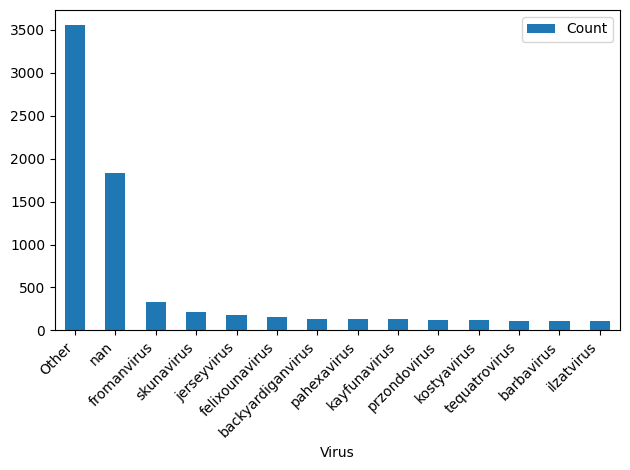

In [300]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(list(counts.items()), columns=['Virus', 'Count'])

# Define threshold (e.g. <=1 gets grouped)
threshold = 100

# Split into major + minor
major = df[df['Count'] > threshold]
minor = df[df['Count'] <= threshold]

# Sum minor counts into "Other"
other_count = minor['Count'].sum()

# Add "Other" row if needed
if other_count > 0:
    major = pd.concat([major, pd.DataFrame([['Other', other_count]], columns=['Virus', 'Count'])])

# Sort again
major = major.sort_values(by='Count', ascending=False)

# Plot
major.plot(kind='bar', x='Virus', y='Count')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()